In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#185FA5', '#F7941D', '#0F6E56', '#533AB7', '#E84E1B']

HERE = Path(os.getcwd())
PROJECT_ROOT = HERE
while not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Cannot find project root")

DATA_PROC = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS   = PROJECT_ROOT / 'outputs'

# Load all files from Phase 4 + 5
events         = pd.read_parquet(DATA_PROC / 'events_clean.parquet')
views          = pd.read_parquet(DATA_PROC / 'views.parquet')
carts          = pd.read_parquet(DATA_PROC / 'carts.parquet')
purchases      = pd.read_parquet(DATA_PROC / 'purchases.parquet')
rfm            = pd.read_parquet(DATA_PROC / 'rfm_features.parquet')
engaged        = pd.read_parquet(DATA_PROC / 'engaged_visitors.parquet')
daily_demand   = pd.read_parquet(DATA_PROC / 'daily_demand.parquet')
item_pop       = pd.read_parquet(DATA_PROC / 'item_popularity.parquet')

print("✓ All data loaded")
print(f"  Events   : {len(events):,}")
print(f"  RFM rows : {len(rfm):,}")
print(f"  Engaged  : {len(engaged):,}")

✓ All data loaded
  Events   : 2,626,570
  RFM rows : 1,407,392
  Engaged  : 408,012


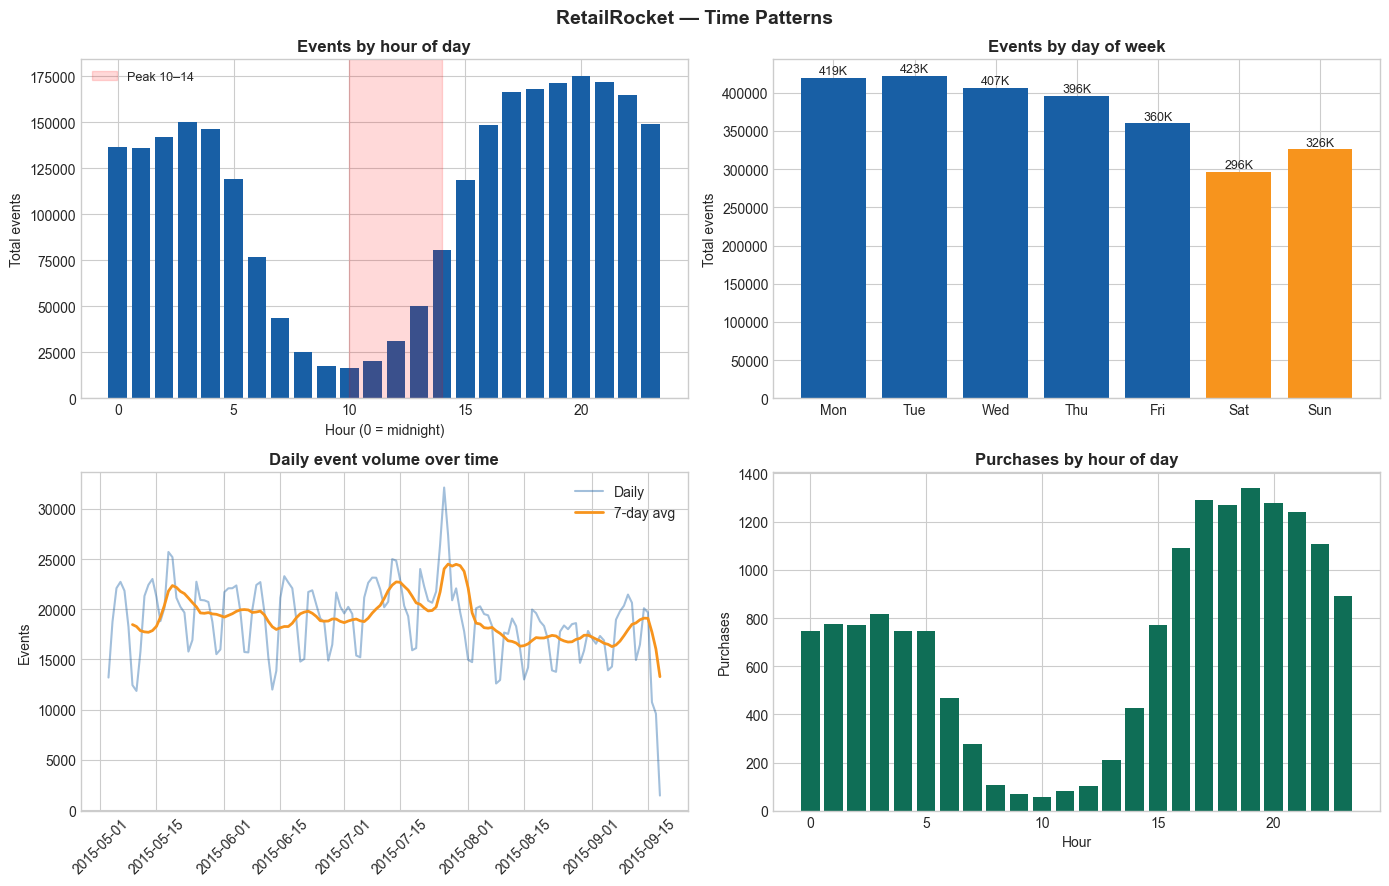

Saved → outputs/eda_time_patterns.png


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('RetailRocket — Time Patterns', fontsize=14, fontweight='bold')

# ── 1. Events by hour ──────────────────────────
hourly = events.groupby('hour').size()
axes[0,0].bar(hourly.index, hourly.values, color=COLORS[0])
axes[0,0].set_title('Events by hour of day', fontweight='bold')
axes[0,0].set_xlabel('Hour (0 = midnight)')
axes[0,0].set_ylabel('Total events')
axes[0,0].axvspan(10, 14, alpha=0.15, color='red', label='Peak 10–14')
axes[0,0].legend(fontsize=9)

# ── 2. Events by day of week ───────────────────
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_colors = [COLORS[0] if i < 5 else COLORS[1] for i in range(7)]
dow = events.groupby('dayofweek').size()
axes[0,1].bar(day_names, dow.values, color=dow_colors)
axes[0,1].set_title('Events by day of week', fontweight='bold')
axes[0,1].set_ylabel('Total events')
# add text labels on bars
for i, v in enumerate(dow.values):
    axes[0,1].text(i, v + 5000, f'{v/1000:.0f}K', ha='center', fontsize=9)

# ── 3. Daily volume over time ──────────────────
daily_vol = events.groupby('date').size().reset_index(name='count')
daily_vol['date'] = pd.to_datetime(daily_vol['date'])
daily_vol['rolling7'] = daily_vol['count'].rolling(7).mean()
axes[1,0].plot(daily_vol['date'], daily_vol['count'],
              color=COLORS[0], alpha=0.4, label='Daily')
axes[1,0].plot(daily_vol['date'], daily_vol['rolling7'],
              color=COLORS[1], linewidth=2, label='7-day avg')
axes[1,0].set_title('Daily event volume over time', fontweight='bold')
axes[1,0].set_ylabel('Events')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()

# ── 4. Purchases by hour ───────────────────────
buy_hour = purchases.groupby('hour').size()
axes[1,1].bar(buy_hour.index, buy_hour.values, color=COLORS[2])
axes[1,1].set_title('Purchases by hour of day', fontweight='bold')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Purchases')

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/eda_time_patterns.png")

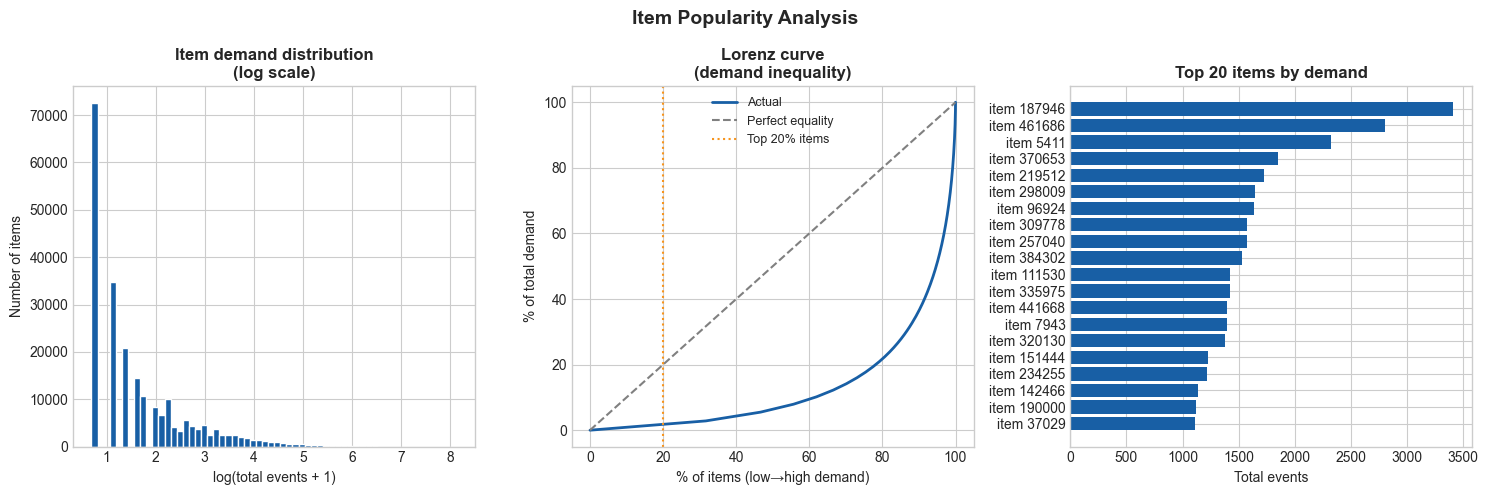

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Item Popularity Analysis', fontsize=14, fontweight='bold')

# ── 1. Log-scale demand distribution ──────────────
axes[0].hist(np.log1p(item_pop['total_events']),
             bins=60, color=COLORS[0], edgecolor='white')
axes[0].set_title('Item demand distribution\n(log scale)', fontweight='bold')
axes[0].set_xlabel('log(total events + 1)')
axes[0].set_ylabel('Number of items')

# ── 2. Lorenz curve — inequality of demand ─────────
sorted_demand = item_pop['total_events'].sort_values().values
cum_demand = np.cumsum(sorted_demand) / sorted_demand.sum()
cum_items  = np.arange(1, len(sorted_demand)+1) / len(sorted_demand)
axes[1].plot(cum_items * 100, cum_demand * 100,
             color=COLORS[0], linewidth=2, label='Actual')
axes[1].plot([0,100], [0,100],
             linestyle='--', color='gray', label='Perfect equality')
axes[1].axvline(20, color=COLORS[1], linestyle=':', label='Top 20% items')
axes[1].set_title('Lorenz curve\n(demand inequality)', fontweight='bold')
axes[1].set_xlabel('% of items (low→high demand)')
axes[1].set_ylabel('% of total demand')
axes[1].legend(fontsize=9)

# ── 3. Top 20 items by total events ───────────────
top20 = item_pop.head(20)
axes[2].barh(
    [f"item {i}" for i in top20['itemid']],
    top20['total_events'],
    color=COLORS[0]
)
axes[2].set_title('Top 20 items by demand', fontweight='bold')
axes[2].set_xlabel('Total events')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_item_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

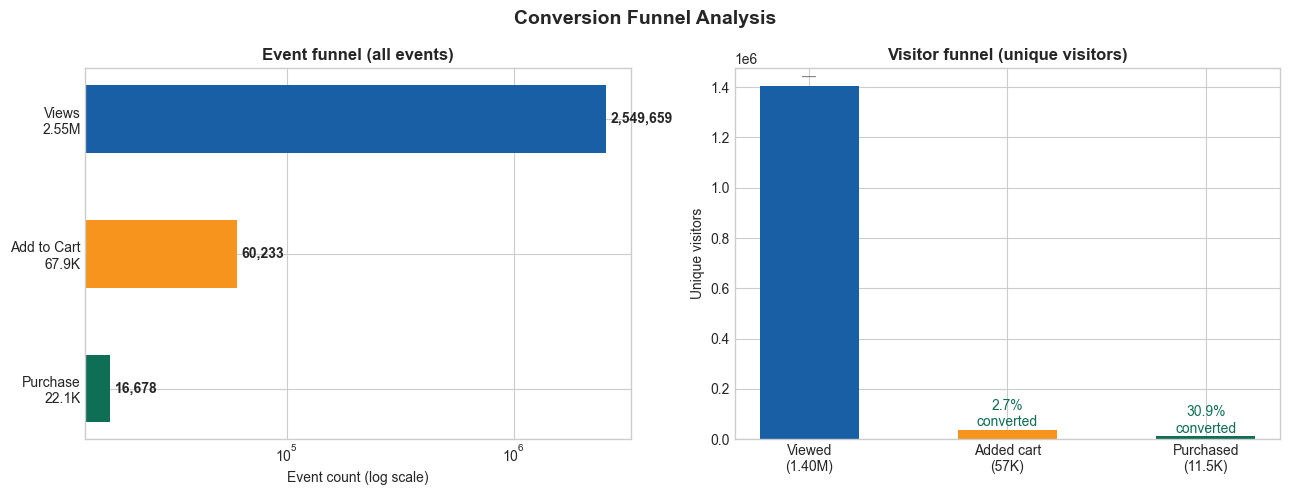

View → Cart  : 2.68% of viewers added to cart
Cart → Buy   : 30.86% of carters actually purchased
View → Buy   : 0.83% overall conversion


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Conversion Funnel Analysis', fontsize=14, fontweight='bold')

# ── 1. Event-level funnel ──────────────────────────
funnel_events = [len(views), len(carts), len(purchases)]
funnel_labels = ['Views\n2.55M', 'Add to Cart\n67.9K', 'Purchase\n22.1K']
funnel_colors = [COLORS[0], COLORS[1], COLORS[2]]

bars = axes[0].barh(funnel_labels, funnel_events, color=funnel_colors, height=0.5)
axes[0].set_title('Event funnel (all events)', fontweight='bold')
axes[0].set_xlabel('Event count (log scale)')
axes[0].set_xscale('log')
axes[0].invert_yaxis()
for bar, val in zip(bars, funnel_events):
    axes[0].text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=10, fontweight='bold')

# ── 2. Visitor-level funnel with drop-off rates ────
v_view  = views['visitorid'].nunique()
v_cart  = carts['visitorid'].nunique()
v_buy   = purchases['visitorid'].nunique()

stages  = ['Viewed\n(1.40M)', 'Added cart\n(57K)', 'Purchased\n(11.5K)']
counts  = [v_view, v_cart, v_buy]
axes[1].bar(stages, counts, color=funnel_colors, width=0.5)
axes[1].set_title('Visitor funnel (unique visitors)', fontweight='bold')
axes[1].set_ylabel('Unique visitors')

# Add drop-off % annotations
dropoffs = ['—',
            f'{v_cart/v_view*100:.1f}%\nconverted',
            f'{v_buy/v_cart*100:.1f}%\nconverted']
for i, (cnt, lbl) in enumerate(zip(counts, dropoffs)):
    axes[1].text(i, cnt + 15000, lbl, ha='center', fontsize=10,
                color=COLORS[2] if i > 0 else 'gray')

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"View → Cart  : {v_cart/v_view*100:.2f}% of viewers added to cart")
print(f"Cart → Buy   : {v_buy/v_cart*100:.2f}% of carters actually purchased")
print(f"View → Buy   : {v_buy/v_view*100:.2f}% overall conversion")

=== BUYER vs NON-BUYER PROFILE ===
                     Buyers (mean)  Non-buyers (mean)  Ratio (B/NB)
recency                      65.20              66.95          0.97
view_count                    8.43               3.67          2.30
cart_count                    1.71               0.10         17.10
view_to_cart_rate             0.42               0.04         10.50
unique_items_viewed           4.64               2.53          1.83


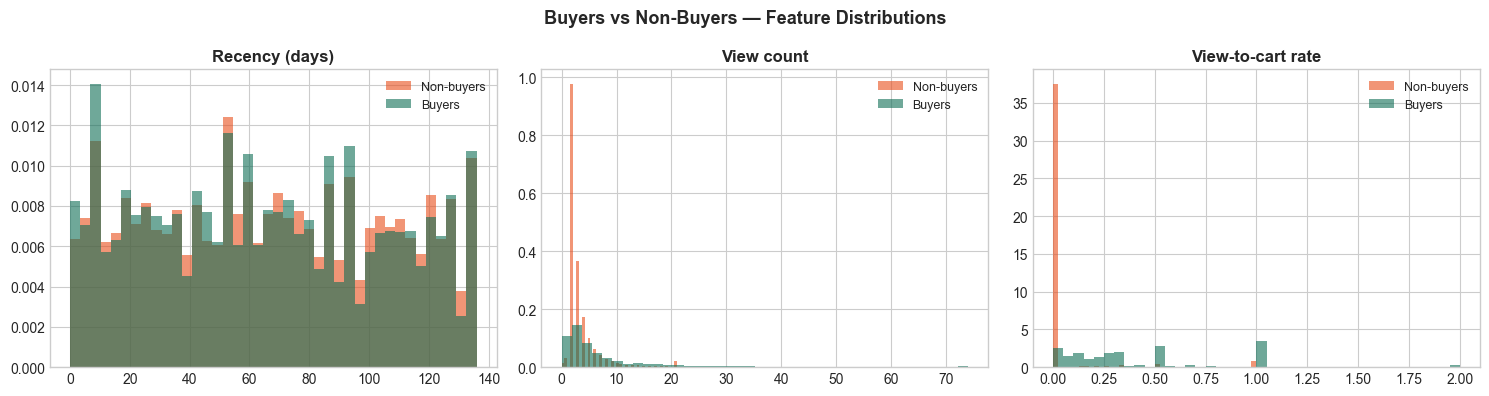

In [5]:
# Split engaged visitors into buyers and non-buyers
buyers     = engaged[engaged['churned'] == 0]
non_buyers = engaged[engaged['churned'] == 1]

print("=== BUYER vs NON-BUYER PROFILE ===")
compare_cols = ['recency', 'view_count', 'cart_count',
                'view_to_cart_rate', 'unique_items_viewed']

comparison = pd.DataFrame({
    'Buyers (mean)'    : buyers[compare_cols].mean().round(2),
    'Non-buyers (mean)': non_buyers[compare_cols].mean().round(2),
})
comparison['Ratio (B/NB)'] = (comparison['Buyers (mean)'] /
                              comparison['Non-buyers (mean)']).round(2)
print(comparison.to_string())

# Plot side-by-side distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Buyers vs Non-Buyers — Feature Distributions',
             fontsize=13, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['recency', 'view_count', 'view_to_cart_rate'],
    ['Recency (days)', 'View count', 'View-to-cart rate']
):
    ax.hist(non_buyers[col].clip(upper=non_buyers[col].quantile(0.99)),
            bins=40, alpha=0.6, color=COLORS[4], label='Non-buyers', density=True)
    ax.hist(buyers[col].clip(upper=buyers[col].quantile(0.99)),
            bins=40, alpha=0.6, color=COLORS[2], label='Buyers', density=True)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_buyer_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

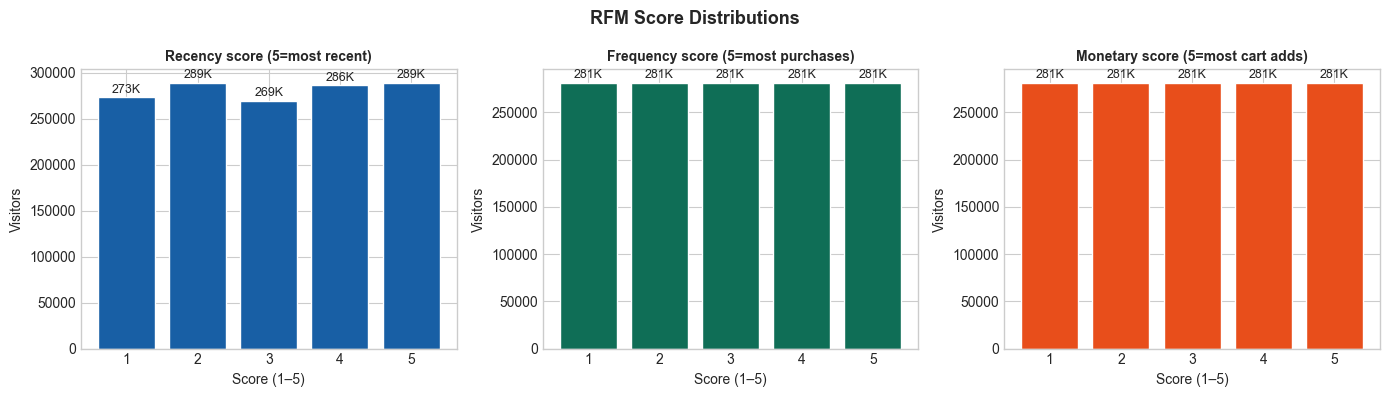

High-value customers (score ≥12): 287,838 (20.5%)
At-risk customers    (score ≤5) : 270,258 (19.2%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('RFM Score Distributions', fontsize=13, fontweight='bold')

for ax, score, color, title in zip(
    axes,
    ['R_score', 'F_score', 'M_score'],
    COLORS[::2],
    ['Recency score (5=most recent)',
     'Frequency score (5=most purchases)',
     'Monetary score (5=most cart adds)']
):
    counts = rfm[score].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Score (1–5)')
    ax.set_ylabel('Visitors')
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 5000, f'{v/1000:.0f}K', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_rfm_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Business insight summary
high_rfm = rfm[rfm['RFM_score'] >= 12]
low_rfm  = rfm[rfm['RFM_score'] <= 5]
print(f"High-value customers (score ≥12): {len(high_rfm):,} ({len(high_rfm)/len(rfm)*100:.1f}%)")
print(f"At-risk customers    (score ≤5) : {len(low_rfm):,} ({len(low_rfm)/len(rfm)*100:.1f}%)")

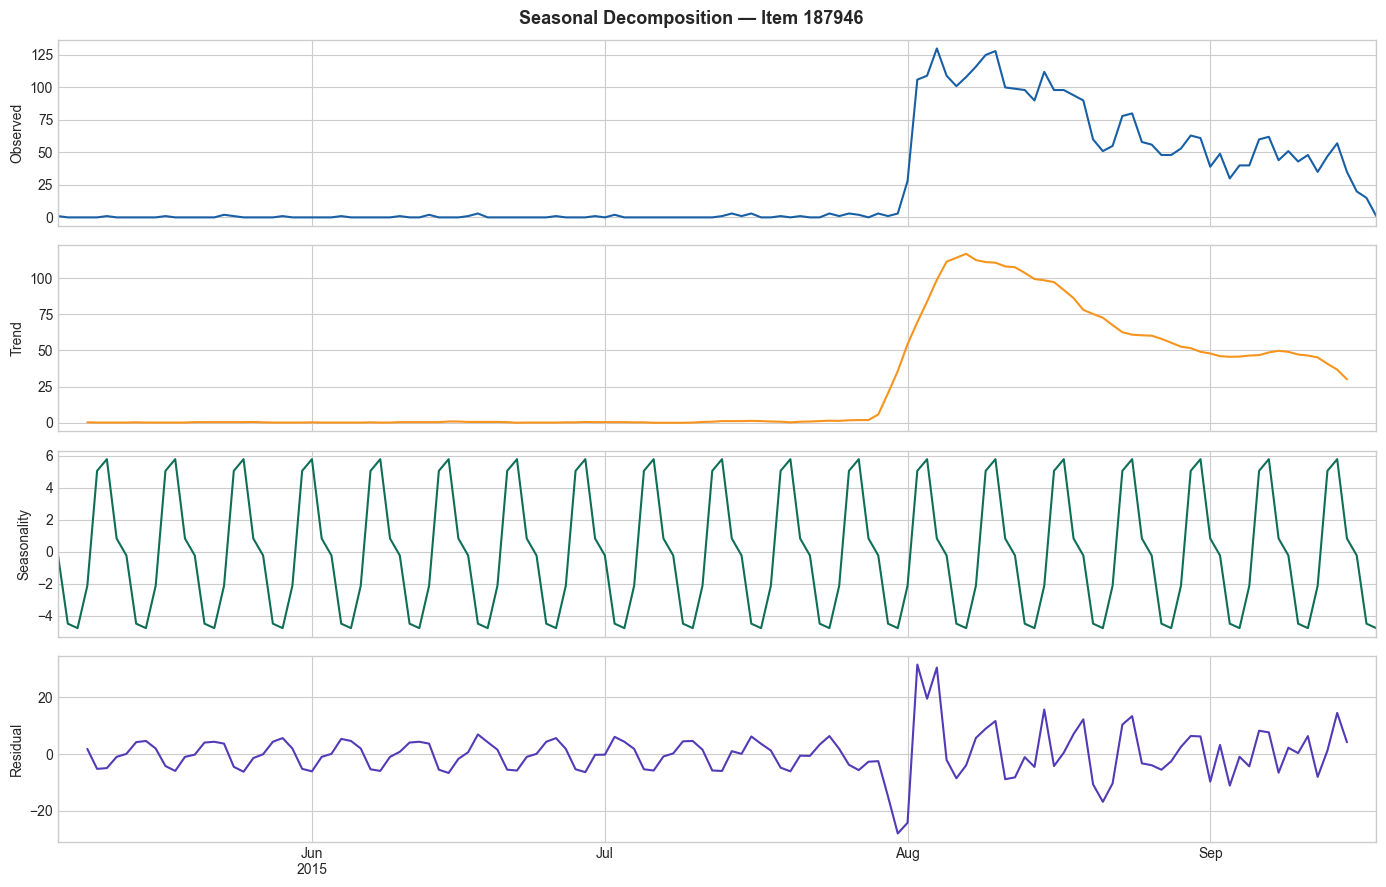


ADF Stationarity Test:
  ADF Statistic : -1.6101
  p-value       : 0.4779
  Stationary?   : NO — needs differencing


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Pick the single top item for decomposition
top_item_id = item_pop.iloc[0]['itemid']
ts = (daily_demand[daily_demand['itemid'] == top_item_id]
      .sort_values('date')
      .set_index('date')['demand'])

# Fill missing dates with 0 (some days had no events for this item)
full_idx = pd.date_range(ts.index.min(), ts.index.max(), freq='D')
ts = ts.reindex(full_idx, fill_value=0)

# Decompose into trend + seasonality + residual
decomp = seasonal_decompose(ts, model='additive', period=7)  # 7 = weekly

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f'Seasonal Decomposition — Item {top_item_id}',
             fontsize=13, fontweight='bold')

decomp.observed.plot(ax=axes[0], color=COLORS[0]); axes[0].set_ylabel('Observed')
decomp.trend.plot(   ax=axes[1], color=COLORS[1]); axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color=COLORS[2]); axes[2].set_ylabel('Seasonality')
decomp.resid.plot(   ax=axes[3], color=COLORS[3]); axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Stationarity test — ADF test
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(ts.dropna())
print(f"\nADF Stationarity Test:")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Stationary?   : {'YES ✓' if adf_result[1] < 0.05 else 'NO — needs differencing'}")

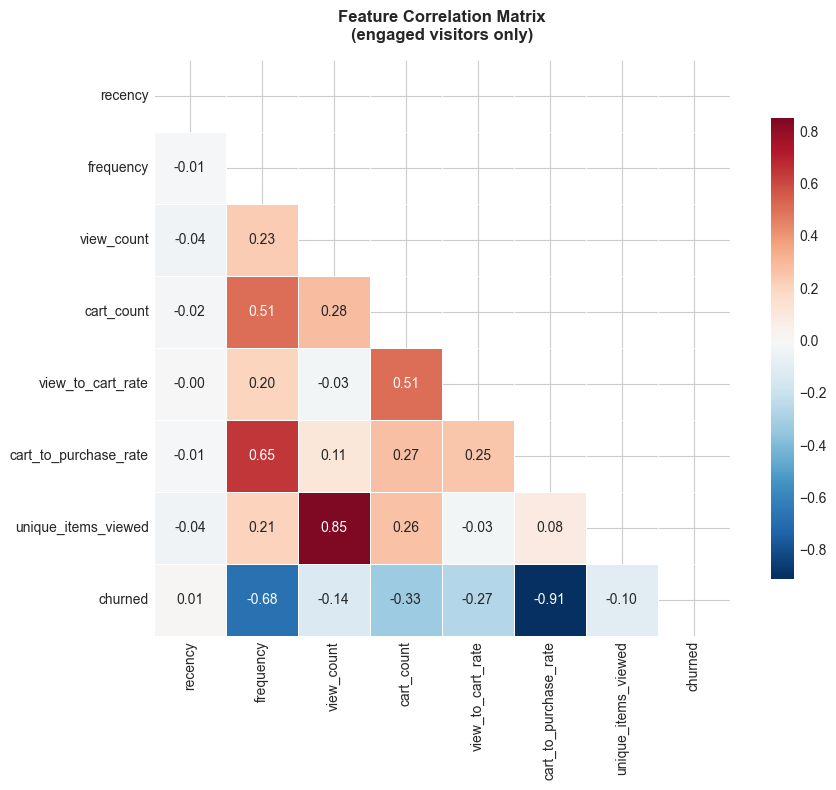


Correlation with 'churned' (higher absolute = more predictive):
cart_to_purchase_rate    0.91
frequency                0.68
cart_count               0.33
view_to_cart_rate        0.27
view_count               0.14
unique_items_viewed      0.10
recency                  0.01


In [12]:
# Select only columns that exist in engaged dataframe
feature_cols_all = ['recency', 'frequency', 'view_count',
                    'cart_count', 'view_to_cart_rate',
                    'cart_to_purchase_rate', 'unique_items_viewed',
                    'RFM_score', 'churned']
feature_cols = [col for col in feature_cols_all if col in engaged.columns]

# Only use engaged visitors (284K) — more relevant than all 1.4M
corr = engaged[feature_cols].corr().round(2)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix\n(engaged visitors only)',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUTS / 'eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlation with churned — feature importance preview
print("\nCorrelation with 'churned' (higher absolute = more predictive):")
churn_corr = corr['churned'].drop('churned').abs().sort_values(ascending=False)
print(churn_corr.to_string())